In [2]:
# https://docs.pytorch.org/vision/main/models/mask_rcnn.html
# since PyTorch offers a MaskRCNN model out of the box, we do not need the Keras and TF based implementation at https://github.com/matterport/Mask_RCNN

In [59]:
import os
from PIL import Image

import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torchvision.models import list_models
from torchvision.models.detection.mask_rcnn import maskrcnn_resnet50_fpn, maskrcnn_resnet50_fpn_v2 # the MaskRCNN family of models are available in the detection module of "torchvision.models"
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights, MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

from torch.hub import set_dir
set_dir(r"../bin/") # this is where the pretrained weights get downloaded and cached

In [6]:
# import the MaskRCNN model builders
# maskrcnn_resnet50_fpn - based on https://arxiv.org/abs/1703.06870
# maskrcnn_resnet50_fpn_v2 - based on https://arxiv.org/abs/2111.11429

In [13]:
print(list_models()) # does contain 'maskrcnn_resnet50_fpn' and 'maskrcnn_resnet50_fpn_v2'

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'fasterrcnn_mobilenet_v3_large_320_fpn', 'fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn', 'fasterrcnn_resnet50_fpn_v2', 'fcn_resnet101', 'fcn_resnet50', 'fcos_resnet50_fpn', 'googlenet', 'inception_v3', 'keypointrcnn_resnet50_fpn', 'lraspp_mobilenet_v3_large', 'maskrcnn_resnet50_fpn', 'maskrcnn_resnet50_fpn_v2', 'maxvit_t', 'mc3_18', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'mvit_v1_b', 'mvit_v2_s', 'quantized_googlenet', 'quantized_inception_v3', 'quantized_mobilenet_v2

In [12]:
print(list_models(module=models)) # does not contain any MaskRCNNs!!!

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [9]:
# look up https://docs.pytorch.org/vision/main/models.html to see how to use PyTorch hub models
# for MaskRCNN - https://docs.pytorch.org/vision/main/models.html#instance-segmentation

# two pretrained models are available
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------
#                                   Weight | Box MAP | Mask MAP | Params | GFLOPS | Recipe
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------
# MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1 | 47.4    | 41.8     | 46.4M  | 333.58 | https://github.com/pytorch/vision/pull/5773
# MaskRCNN_ResNet50_FPN_Weights.COCO_V1    | 37.9    | 34.6     | 44.4M  | 134.38 | https://github.com/pytorch/vision/tree/main/references/detection#mask-r-cnn
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------

In [25]:
# https://github.com/pytorch/vision/blob/main/torchvision/models/detection/mask_rcnn.py
model_0 = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1)
model_1 = maskrcnn_resnet50_fpn_v2(weights=MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1)

In [29]:
image = Image.open(r"../images/sa_9286.jpg")
image.mode

'RGB'

In [27]:
preprocess = MaskRCNN_ResNet50_FPN_Weights.COCO_V1.transforms() # transformations needed to be applied before passing the image to the model

In [50]:
preprocessed_image = preprocess(image).unsqueeze(0) # input is required to be an instance of class PIL.Image

In [53]:
preprocessed_image.shape

torch.Size([1, 3, 1024, 1024])

In [49]:
# pytorch doesn't support .mean() for boolean or integer tensors?????
(torch.tensor(np.array(np.unstack(np.array(image), axis=-1))) / 255 == preprocessed_image).type(torch.float16).mean() # don't really need a wrapper for that do we???

tensor(1., dtype=torch.float16)

In [54]:
model_0.eval()
preds_0 = model_0(preprocessed_image)

In [57]:
preds_0[0] # is a list with one element

{'boxes': tensor([[340.5366, 618.6191, 422.8091, 772.0653],
         [241.1581, 710.1382, 293.2354, 873.8988],
         [275.9989,  94.9243, 747.8994, 920.5742],
         [717.1577, 730.7380, 876.3149, 857.6635],
         [171.6315, 714.2812, 751.1089, 912.1245],
         [544.2995, 692.1385, 608.3538, 752.4850],
         [228.8713, 516.1360, 734.2001, 913.1660],
         [130.6029, 819.0883, 310.8122, 904.3308],
         [283.1114, 703.4499, 344.3967, 760.3895],
         [470.9462, 687.6047, 517.3552, 736.8723],
         [319.2090, 701.2980, 358.5216, 770.5349],
         [425.0327, 695.7509, 599.2067, 775.6616],
         [456.6674, 682.5972, 525.7921, 787.2469],
         [361.3245, 588.1559, 393.5581, 629.3478],
         [320.2863, 696.4735, 344.1927, 721.8599],
         [241.5188, 712.2442, 347.2899, 870.9805],
         [350.2301, 361.8828, 819.1492, 897.5398],
         [302.2004, 697.6033, 370.3486, 783.3394],
         [139.4184, 780.1689, 615.5005, 908.8075],
         [129.7926, 75

In [58]:
# we get bounding boxes and masks :)
preds_0[0]["boxes"]

tensor([[340.5366, 618.6191, 422.8091, 772.0653],
        [241.1581, 710.1382, 293.2354, 873.8988],
        [275.9989,  94.9243, 747.8994, 920.5742],
        [717.1577, 730.7380, 876.3149, 857.6635],
        [171.6315, 714.2812, 751.1089, 912.1245],
        [544.2995, 692.1385, 608.3538, 752.4850],
        [228.8713, 516.1360, 734.2001, 913.1660],
        [130.6029, 819.0883, 310.8122, 904.3308],
        [283.1114, 703.4499, 344.3967, 760.3895],
        [470.9462, 687.6047, 517.3552, 736.8723],
        [319.2090, 701.2980, 358.5216, 770.5349],
        [425.0327, 695.7509, 599.2067, 775.6616],
        [456.6674, 682.5972, 525.7921, 787.2469],
        [361.3245, 588.1559, 393.5581, 629.3478],
        [320.2863, 696.4735, 344.1927, 721.8599],
        [241.5188, 712.2442, 347.2899, 870.9805],
        [350.2301, 361.8828, 819.1492, 897.5398],
        [302.2004, 697.6033, 370.3486, 783.3394],
        [139.4184, 780.1689, 615.5005, 908.8075],
        [129.7926, 755.3879, 348.4113, 905.8096],


In [68]:
bboxes_0 = draw_bounding_boxes(image=preprocessed_image[0], boxes=preds_0[0]["boxes"])#, labels=preds_0[0]["labels"])

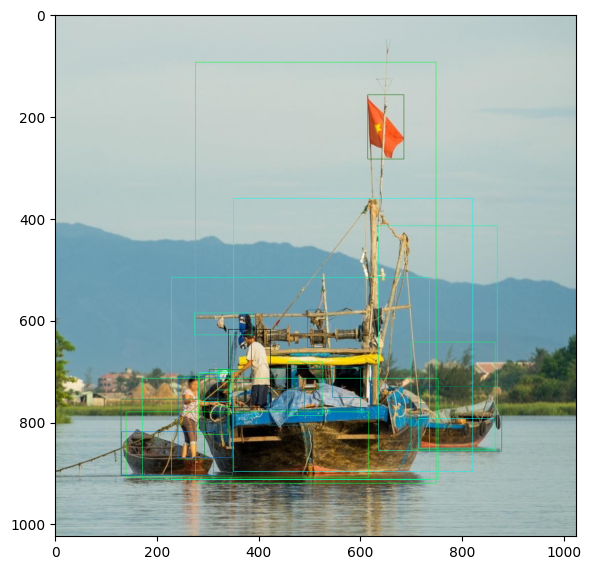

In [73]:
fig, axes = plt.subplots()
fig.set_size_inches(6, 6)
axes.imshow(np.stack(bboxes_0, axis=2)) # works :)
plt.tight_layout()
plt.show()

In [84]:
masks_0 = draw_segmentation_masks(image=preprocessed_image[0], masks=preds_0[0]["masks"].squeeze().type(torch.bool)) # squeeze() converts the dtype to floats which the function throws an exception

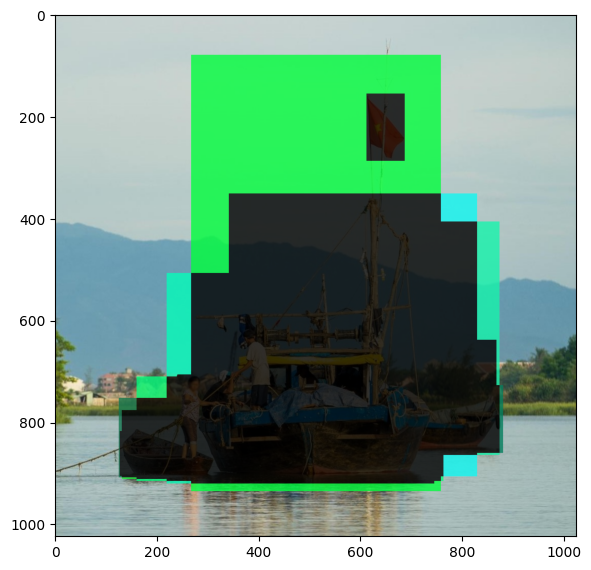

In [85]:
fig, axes = plt.subplots()
fig.set_size_inches(6, 6)
axes.imshow(np.stack(masks_0, axis=2)) # that's awful
plt.tight_layout()
plt.show()